# Trabalho Prático de Mineração de Dados — Fase 2
## Utilização de LLMs e Análise Comparativa com Diretrizes de IA Responsável

**Disciplina:** Mineração de Dados  
**Grupo:** 
Davi Oliveira Sad - 2023096043 <br>
Gabrielly Xavier dos Santos - 2024023724 <br>
Júlia Luíza Costa de Toledo - 2024008431 <br>
Rafael Vinicius de Sant’Ana Mathias - 2023087834 <br> 
**Dataset:** Mushroom    
**Tarefa de mineração:** Classificação   
**Data da entrega:** 14/06/2026  

---

## Objetivo deste notebook

Este notebook documenta a Fase 2 do Trabalho Prático. O objetivo é usar uma ou mais LLMs como apoio à construção da solução de mineração de dados e comparar duas trilhas de interação:

- **Trilha A — baseline:** interação com a LLM sem explicitar diretrizes de IA responsável;
- **Trilha B — guiada:** interação com a LLM explicitando as diretrizes de IA responsável escolhidas pelo grupo.

O foco não é apenas mostrar prompts e respostas. O grupo deve analisar criticamente se a explicitação das diretrizes levou a diferenças concretas na solução proposta, por exemplo em:

- escolha de algoritmos;
- tratamento dos dados;
- seleção de atributos;
- definição de parâmetros;
- métricas de avaliação;
- interpretabilidade;
- privacidade;
- análise de viés;
- custo computacional;
- qualidade da documentação.

> **Importante:** este notebook é um modelo de estrutura. Ele contém exemplos, placeholders e código genérico. O grupo deve substituir os campos indicados por informações reais do seu dataset, das interações com LLMs e dos experimentos efetivamente realizados.


# Como usar este notebook

Este notebook foi organizado seguindo a estrutura esperada para a Fase 2:

1. **Business Understanding**
2. **Data Understanding & Data Preparation**
3. **Modeling**
4. **Evaluation**
5. **Checklist final**

Ao longo do notebook, os trechos marcados entre colchetes, como `[INSERIR LINK DA CONVERSA]`, devem ser preenchidos pelo grupo.

## Diferença entre exemplo e entrega real

- Células de **exemplo** mostram como organizar a entrega.
- Células com **placeholders** indicam pontos que devem ser preenchidos.
- Células de **código** são genéricas e podem precisar de adaptação ao dataset.
- Nenhum resultado experimental deve ser inventado.
- Toda conclusão empírica deve estar apoiada em uma tabela, gráfico ou execução de código.


# 0. Controle da entrega e rastreabilidade

Esta seção registra informações mínimas para tornar o trabalho rastreável e auditável.

| Item | Valor |
|---|---|
| Nome do dataset | Mushroom |
| Link público do dataset |https://archive.ics.uci.edu/dataset/73/mushroom |
| Número de linhas | 8.124 |
| Número de colunas | 22 |
| Tarefa de mineração | Classificação |
| LLM usada na Trilha A | Google Gemini |
| LLM usada na Trilha B | Google Gemini |
| Link da conversa — Trilha A | [SESSÃO1](https://gemini.google.com/share/b1034394d755); [SESSÃO2](); [SESSÃO3]() |
| Link da conversa — Trilha B | [SESSÃO1](); [SESSÂO2](); [SESSÂO3]() |

## Diretrizes de IA responsável escolhidas

| Diretriz | Justificativa da escolha | Como será explicitada na Trilha B |
|---|---|---|
| Segurança, confiabilidade e robustez | O problema possui custo de erro assimétrico, pois um falso negativo pode expor pessoas ao risco de intoxicação. Por isso, a solução precisa priorizar redução de erros críticos e comportamento consistente do modelo. | A Trilha B solicitará foco explícito na classe venenosa, uso de métricas como recall e F1 para a classe de maior risco, além de sugestões de pesos de classe, validação estratificada e tratamento cuidadoso dos dados faltantes. |
| Transparência e explicabilidade | A decisão precisa ser compreensível e auditável, já que os atributos são categóricos e o uso prático do modelo exige confiança em suas justificativas. | A Trilha B pedirá modelos interpretáveis, como árvore de decisão, além de tradução dos códigos do dataset para linguagem natural, visualização das regras e indicação dos atributos mais relevantes para a predição. |

> **Propósito pedagógico:** esta seção evita que a análise fique solta ou apenas narrativa. O avaliador precisa conseguir identificar o que foi perguntado à LLM, quando, em qual modelo e com qual objetivo.


In [1]:
# Configurações iniciais do notebook
# Esta célula centraliza imports e parâmetros gerais.
# O grupo deve adaptar os caminhos, nomes de colunas e tipo de tarefa.

import os
import time
import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Caminho para o dataset.
# Exemplos:
# DATA_PATH = "dados/dataset.csv"
# DATA_PATH = "/content/dataset.csv"
DATA_PATH = "agaricus-lepiota.data"

# Tipo de tarefa do TP.
# Opções sugeridas:
# - "padroes_frequentes"
# - "agrupamento"
# - "classificacao"
TASK_TYPE = "classificacao"

# Coluna-alvo, se aplicável.
# Para padrões frequentes ou agrupamento, normalmente pode ser None.
TARGET_COLUMN = "class"

# Coluna ou conjunto de colunas usadas para gerar transações, se o TP for de padrões frequentes.
TRANSACTION_COLUMN = None

print("Configuração carregada.")
print(f"Tarefa definida: {TASK_TYPE}")
print(f"Dataset: {DATA_PATH}")


Configuração carregada.
Tarefa definida: classificacao
Dataset: agaricus-lepiota.data


# 1. Business Understanding

Nesta seção, o grupo deve explicar o problema, o contexto dos dados, a relevância da tarefa e a hipótese experimental sobre o uso das diretrizes de IA responsável.

A seção deve responder:

1. Qual problema será investigado?
2. Por que o dataset é relevante?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da análise?
5. Quais diretrizes de IA responsável foram escolhidas?
6. Por que essas diretrizes são pertinentes ao problema?
7. O que se espera que mude quando essas diretrizes são explicitadas à LLM?


## 1.1 Descrição do problema de negócio

- **Contexto:** A identificação correta de cogumelos é uma tarefa crítica de segurança alimentar. Em situações de campo, um erro de classificação pode levar ao consumo acidental de uma espécie tóxica, com consequências graves para a saúde humana.

- **Problema:** O objetivo deste trabalho é construir um classificador capaz de distinguir cogumelos comestíveis de venenosos a partir de características morfológicas e ecológicas. Como todas as variáveis da base são categóricas, a tarefa exige codificação adequada e avaliação cuidadosa do modelo para reduzir ao máximo os falsos negativos, isto é, casos em que um cogumelo venenoso seria classificado como comestível.

- **Possíveis interessados:** Consumidores, micologistas, profissionais de saúde, órgãos de vigilância sanitária e desenvolvedores de aplicativos de apoio à identificação de espécies.

- **Decisões apoiadas pela análise:** O modelo pode apoiar triagens iniciais de segurança, orientar guias de identificação, auxiliar aplicativos de consulta em campo e servir como ferramenta educacional para reconhecer padrões associados à toxicidade.

- **Limitações iniciais conhecidas:** A base é composta apenas por atributos nominais, não contém medições laboratoriais e descreve apenas uma fração da diversidade de cogumelos existente. Além disso, o atributo stalk-root possui valores ausentes representados por '?', o que exige tratamento específico antes da modelagem.

> Este texto contextualiza o problema de mineração de dados na perspectiva de classificação supervisionada e destaca o risco assimétrico associado ao erro na classe venenosa.


## 1.2 Objetivo do dataset, origem e características gerais

### Objetivo do dataset

O Mushroom Dataset foi criado para registrar atributos físicos e ecológicos de cogumelos e relacioná-los à sua classe de segurança alimentar. Neste trabalho, o dataset será usado para treinar e avaliar modelos de classificação capazes de prever se um espécime é comestível ou venenoso a partir de suas características observáveis. Esse objetivo é adequado porque transforma um problema biológico em um problema supervisionado de predição binária, no qual a interpretação correta dos atributos pode contribuir para reduzir riscos de intoxicação.

### Origem dos dados

Os dados foram disponibilizados pelo UCI Machine Learning Repository e têm origem no Audubon Society Field Guide (1981). A base Mushroom é amplamente usada em pesquisas de classificação por ser pequena, balanceada e inteiramente categórica, o que a torna apropriada para comparar estratégias de pré-processamento e diferentes algoritmos supervisionados.

Link público: https://archive.ics.uci.edu/dataset/73/mushroom

### Características do dataset

| Coluna | Tipo esperado | Descrição | Relevância para a tarefa |
|---|---|---|---|
| class | Categórica | Comestível (e) ou venenoso (p). | Variável-alvo que define a predição do modelo. |
| cap-shape | Categórica | Formato do chapéu, como sino, cônico, convexo, plano, afundado ou saliente. | Ajuda a diferenciar padrões morfológicos iniciais. |
| cap-surface | Categórica | Superfície do chapéu, como fibrosa, sulcada, escamosa ou lisa. | Complementa a análise visual da estrutura externa. |
| cap-color | Categórica | Cor do chapéu, como marrom, bege, cinza, branco, amarelo e outras. | Fornece um sinal visual básico de diferenciação. |
| bruises? | Categórica | Indica presença ou ausência de hematomas/manchas. | Pode sinalizar características morfológicas úteis para separar espécies. |
| odor | Categórica | Amêndoa, anis, creosoto, peixe, fétido, mofo, nenhum, pungente ou picante. | Um dos atributos mais discriminantes para toxicidade. |
| gill-attachment | Categórica | Tipo de fixação das lâminas no caule, como adnatas, descendentes, livres ou entalhadas. | Ajuda a caracterizar a estrutura interna do cogumelo. |
| gill-spacing | Categórica | Espaçamento entre as lâminas, como fechado, aglomerado ou distante. | Contribui para distinguir padrões taxonômicos. |
| gill-size | Categórica | Tamanho das lâminas, classificado como largo ou estreito. | Indica diferenças estruturais relevantes para a classificação. |
| gill-color | Categórica | Cor das lâminas, com várias possibilidades como preto, marrom, bege, cinza, rosa, branco e amarelo. | Forte indicador visual e taxonômico. |
| stalk-shape | Categórica | Formato do caule, afunilado ou alargado. | Ajuda a descrever a morfologia do espécime. |
| stalk-root | Categórica | Tipo de raiz do estipe, incluindo valores ausentes representados por '?'. | Exige tratamento de dados faltantes antes da modelagem. |
| stalk-surface-above-ring | Categórica | Superfície do caule acima do anel, como fibrosa, escamosa, sedosa ou lisa. | Complementa a descrição morfológica do caule. |
| stalk-surface-below-ring | Categórica | Superfície do caule abaixo do anel, como fibrosa, escamosa, sedosa ou lisa. | Pode revelar padrões complementares à parte superior do caule. |
| stalk-color-above-ring | Categórica | Cor do caule acima do anel. | Importante para distinguir variações visuais da espécie. |
| stalk-color-below-ring | Categórica | Cor do caule abaixo do anel. | Complementa a análise da coloração do estipe. |
| veil-type | Categórica | Tipo de véu, parcial ou universal. | Característica anatômica útil para a identificação. |
| veil-color | Categórica | Cor do véu, como marrom, laranja, branco ou amarelo. | Ajuda na diferenciação morfológica. |
| ring-number | Categórica | Número de anéis no caule, como nenhum, um ou dois. | Informa uma característica estrutural relevante. |
| ring-type | Categórica | Tipo de anel, como evanescente, pendente, grande, nenhum, bainha ou zona. | Pode ser altamente informativo para a identificação. |
| spore-print-color | Categórica | Cor da impressão dos esporos. | Importante para diferenciar padrões taxonômicos e biológicos. |
| population | Categórica | Padrão populacional, como abundante, agrupado, numeroso, disperso, vários ou solitário. | Ajuda a contextualizar o padrão de crescimento. |
| habitat | Categórica | Ambiente onde o cogumelo cresce, como gramados, folhas, florestas, lixo ou trilhas. | Ajuda a contextualizar o nicho ecológico da espécie. |

### Relação com o problema de negócio

O dataset é adequado porque apresenta exatamente o tipo de relação que o problema de negócio exige: atributos observáveis e uma classe binária clara, permitindo treinar modelos que indiquem risco de toxicidade com base em padrões estruturais e ambientais. Como a diferença entre um erro comum e um erro crítico é enorme neste contexto, a base oferece um cenário realista para avaliar não apenas desempenho global, mas também a capacidade do classificador de identificar corretamente a classe venenosa.


## 1.3 Diretrizes selecionadas e hipótese experimental

### Diretrizes selecionadas

| Diretriz | Por que é pertinente ao problema? | Possível efeito esperado na solução da LLM |
|---|---|---|
| Segurança, confiabilidade e robustez | O problema é de alto impacto, porque um falso negativo pode colocar a saúde de uma pessoa em risco. Isso exige modelos estáveis, com avaliação rigorosa e foco explícito na classe venenosa. | Espera-se que a LLM proponha validação mais cuidadosa, tratamento de desequilíbrios de erro, ajuste de pesos de classe e priorização de métricas como recall e F1 para a classe venenosa. |
| Transparência e explicabilidade | A decisão precisa ser auditável por especialistas e compreensível para usuários leigos. Como os atributos são todos categóricos, é importante entender quais variáveis sustentam a predição. | Espera-se que a LLM favoreça modelos interpretáveis, como árvore de decisão e regressão logística, além de sugerir visualizações, análise de importância de atributos e explicações em linguagem natural. |

### Hipótese experimental

Ao explicitar as diretrizes de segurança, confiabilidade, robustez, transparência e explicabilidade, esperamos que a LLM proponha uma solução mais conservadora e auditável, com maior atenção à classe venenosa, uso de métricas apropriadas para risco assimétrico e preferência por algoritmos interpretáveis. Em comparação com uma resposta baseline, a solução guiada deve reduzir a chance de recomendações excessivamente genéricas e orientar melhor a escolha do modelo, do pré-processamento e da avaliação.



### Evidências que serão analisadas

Para avaliar a hipótese, compararemos as trilhas quanto a:

- algoritmos sugeridos;
- etapas de preparação dos dados;
- parâmetros recomendados;
- métricas propostas;
- justificativas técnicas;
- riscos apontados;
- limitações reconhecidas;
- aderência às diretrizes escolhidas.


## 1.4 Interações com LLM — Business Understanding

### Trilha A — baseline

**Modelo utilizado:** Gemini   
**Data de acesso:** 12/06/2026    
**Link da conversa:** https://gemini.google.com/share/b1034394d755   
**Subtarefa:** obter apoio para formular o Business Understanding.   

#### Prompt principal — baseline

```text
Estou fazendo um trabalho de Mineração de Dados com o dataset https://archive.ics.uci.edu/dataset/73/mushroom.

A tarefa é de classificação, com objetivo de classificar cogumelos como comestíveis ou tóxicos.

Ajude-me a formular o Business Understanding, incluindo objetivo do dataset,

origem dos dados, características gerais e relação com o problema.
```

#### Síntese da resposta da LLM

Projeto: Classificação de Cogumelos Silvestres
1. Contexto do Problema <br>
A identificação visual de cogumelos é uma prática de altíssimo risco, dada a extrema semelhança entre espécies comestíveis e venenosas. Um erro de classificação pode resultar em intoxicações severas ou morte. Este projeto visa construir um modelo preditivo capaz de atuar como uma ferramenta de segurança, classificando a edibilidade dos fungos.

2. Objetivo de Negócio e Métrica Principal<br>
Desenvolver um sistema de suporte à decisão focado em zerar o risco fatal.

    Risco Crítico: O custo de um Falso Negativo (classificar um cogumelo tóxico como comestível) é catastrófico.

Risco Aceitável: Um Falso Positivo (classificar um comestível como tóxico) gera apenas desperdício de alimento seguro.

Foco do Modelo: Em vez de focar apenas na Acurácia global, a prioridade absoluta de negócio é maximizar o Recall (Sensibilidade) em relação à classe tóxica.

3. Visão Geral dos Dados<br>
Origem: UCI Machine Learning Repository (1987), extraídos do The Audubon Society Field Guide to North American Mushrooms (1981). Descreve espécies da América do Norte.

Volume: 8.124 instâncias.

Features: 22 atributos preditivos.

Natureza: 100% dos dados são categóricos (representados por códigos em letras).

Variável Alvo (Target): Binária e relativamente balanceada:

e (comestível): ~51.8%

p (tóxico/desconhecido): ~48.2%

4. Entendimento das Variáveis (Domain Knowledge)
Os atributos descrevem a morfologia e a ecologia dos cogumelos. Destacam-se:

    Visuais: Cor, formato e superfície do chapéu, lamelas e talo.

    Olfativas: O atributo odor possui historicamente um alto ganho de informação. Odores de amêndoa/anis costumam indicar edibilidade, enquanto odores químicos ou fétidos indicam toxicidade.

    Ecológicas: O habitat e a população indicam o ambiente de proliferação do fungo, sendo fortes marcadores biológicos de espécie.

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini    
**Data de acesso:** 12/06/2026    
**Link da conversa:** https://gemini.google.com/share/2179317d6a63       
**Subtarefa:** obter apoio para formular o Business Understanding considerando as diretrizes escolhidas.   

#### Prompt principal — guiado

```text
Estou fazendo um trabalho de Mineração de Dados com o dataset https://archive.ics.uci.edu/dataset/73/mushroom.

A tarefa é de classificação, com objetivo de classificar cogumelos como comestíveis ou tóxicos.

Ajude-me a formular o Business Understanding, incluindo objetivo do dataset,

origem dos dados, características gerais e relação com o problema.

Considere explicitamente as seguintes diretrizes de IA responsável:
1. Segurança, confiabilidade e robustez: O problema é de alto impacto, porque um falso negativo pode colocar a saúde de uma pessoa em risco. Isso exige modelos estáveis, com avaliação rigorosa e foco explícito na classe venenosa. | Espera-se que a LLM proponha validação mais cuidadosa, tratamento de desequilíbrios de erro, ajuste de pesos de classe e priorização de métricas como recall e F1 para a classe venenosa.
2. Transparência e explicabilidade:A decisão precisa ser auditável por especialistas e compreensível para usuários leigos. Como os atributos são todos categóricos, é importante entender quais variáveis sustentam a predição. | Espera-se que a LLM favoreça modelos interpretáveis, como árvore de decisão e regressão logística, além de sugerir visualizações, análise de importância de atributos e explicações em linguagem natural.
Além da descrição do problema, indique riscos, limitações e critérios que deveriam
orientar a solução de mineração de dados.
```

#### Síntese da resposta da LLM

1. Visão Geral do Dataset<br>
Escopo Biológico: Dados de 23 espécies de cogumelos com lamelas (Agaricus e Lepiota) catalogadas no The Audubon Society Field Guide (1981).

Estrutura: 8.124 instâncias e 22 atributos (100% categóricos e nominais).

Distribuição: Classes razoavelmente balanceadas (~51,8% Comestíveis vs. ~48,2% Venenosos).

2. Diretrizes de IA Responsável (Segurança Vital)<br>
Este não é um problema estatístico comum; é uma questão de saúde pública.

Métricas de Avaliação: Foco absoluto em Recall (Sensibilidade) de 100% para a classe tóxica. A acurácia global é secundária.

Penalização de Erros: Exige o uso de pesos de classe (class weights) para forçar o algoritmo a ser extremamente conservador, tratando os Falsos Negativos com severidade matemática.

Transparência (White-Box): O modelo deve ser auditável e interpretável. Prioridade para Árvores de Decisão e Regressão Logística, permitindo a extração de Feature Importance e regras em linguagem natural.

3. Riscos e Limitações<br>
Domain Shift: O dataset é geograficamente restrito à América do Norte. Aplicar as regras geradas em fungos de outras partes do mundo é um risco letal.

Dados Faltantes: O atributo stalk-root contém valores ocultos representados por "?", exigindo imputação cuidadosa para não gerar ruídos.

Critério de Sucesso Final: A solução deve ser capaz de reduzir a complexidade técnica a regras heurísticas simples que possam ser validadas pela literatura micológica.

4. Estratégia de Codificação (Encoding)<br>
Considerando a natureza dos dados e os algoritmos propostos, a melhor escolha é o One-Hot Encoding (OHE) (ou Dummy Variables).

Como todos os atributos são estritamente nominais, não existe uma relação de grandeza ou hierarquia entre as categorias (por exemplo, no atributo "cor do chapéu", o vermelho não é matematicamente maior que o amarelo). O uso do Ordinal Encoding (que atribui números como 1, 2, 3) introduziria uma ordem falsa que os algoritmos poderiam interpretar erroneamente.

Impacto na Regressão Logística: O OHE é obrigatório aqui. Ele permite que o modelo isole cada categoria e calcule coeficientes exatos indicando o risco isolado (ex: o peso exato de ter "odor fétido").

Impacto nas Árvores de Decisão: Embora as árvores consigam lidar matematicamente com Ordinal Encoding melhor do que modelos lineares, o OHE garante divisões puramente lógicas ("O chapéu é vermelho? Sim ou Não") e regras mais fáceis de traduzir para linguagem natural.

Como o dataset tem apenas 22 variáveis, a expansão dimensional gerada pelo One-Hot Encoding (que resultará em cerca de 100 a 120 colunas finais) é perfeitamente suportável para os algoritmos de classificação modernos, não causando perda de performance.


## 1.5 Análise crítica das trilhas — Business Understanding

| Critério | Trilha A — baseline | Trilha B — guiada | Diferença observada |
|---|---|---|---|
| Clareza do problema | Definiu corretamente a tarefa como classificação binária de cogumelos comestíveis e tóxicos, com ênfase no valor de negócio de evitar intoxicações. | Manteve a mesma definição do problema, mas conectou explicitamente a solução às diretrizes de segurança, confiabilidade, robustez, transparência e explicabilidade. | A Trilha B ampliou a clareza do problema ao transformá-lo em um caso de alto risco, não apenas em um exercício de classificação. |
| Relação com o dataset | Descreveu a origem, o volume, a natureza categórica e alguns atributos relevantes, mas de forma mais geral. | Além de repetir as características centrais, já antecipou implicações práticas do dataset para encoding, auditoria e escolha de modelo. | A Trilha B conectou melhor os dados às decisões técnicas de modelagem. |
| Consideração das diretrizes | Não explicitou diretrizes de IA responsável. | Incorporou diretamente segurança, confiabilidade, robustez, transparência e explicabilidade no raciocínio da solução. | A Trilha B mudou o foco de uma resposta descritiva para uma resposta orientada por princípios de IA responsável. |
| Identificação de riscos | Reconheceu o risco crítico do falso negativo e a necessidade de priorizar recall da classe tóxica. | Reforçou o risco assimétrico e adicionou riscos de uso indevido, necessidade de class weights, domain shift e tratamento de valores ausentes. | A Trilha B foi mais completa e operacionalizou melhor os riscos. |
| Qualidade da justificativa | A justificativa é tecnicamente correta, com boa noção de domínio, mas ainda genérica em relação ao pipeline de modelagem. | A justificativa é mais robusta, pois liga o problema a escolhas concretas de pré-processamento, métricas e interpretabilidade. | A Trilha B oferece uma base mais útil para implementar a solução de fato. |
| Erros ou omissões | Não detalhou encoding, tratamento de missing values nem como a explicabilidade seria materializada no modelo. | Incluiu OHE, pesos de classe, modelos interpretáveis e cuidados com valores ausentes, embora ainda seja uma resposta de alto nível. | A Trilha B reduziu omissões importantes, mesmo sem chegar ao nível de implementação completa. |

### Síntese crítica

A comparação entre as duas trilhas mostra que a explicitação das diretrizes de IA responsável produziu uma melhoria concreta no Business Understanding. A Trilha A já reconheceu o caráter crítico do problema e indicou corretamente que o recall da classe tóxica é mais importante do que a acurácia global, mas sua resposta permaneceu mais geral e menos conectada à implementação.

A Trilha B foi mais forte porque transformou os princípios escolhidos em orientações técnicas claras: reforçou a necessidade de modelos interpretáveis, sugeriu pesos de classe para penalizar falsos negativos, recomendou One-Hot Encoding para variáveis nominais e apontou limitações como valores ausentes e domain shift. Isso torna a resposta mais útil para a etapa de modelagem e mais coerente com um contexto de risco à saúde.

Como ponto de atenção, a Trilha B ainda mantém a discussão em nível conceitual e não substitui a validação experimental. Mesmo assim, ela é superior à baseline porque oferece critérios de decisão mais rastreáveis e alinhados ao problema real de segurança alimentar.



# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve explorar o dataset, identificar problemas de qualidade dos dados e preparar os dados para a etapa de modelagem.

Além disso, deve registrar como a LLM foi usada para apoiar:

- exploração inicial;
- identificação de problemas;
- tratamento de valores ausentes;
- transformação de atributos;
- seleção de variáveis;
- preparação específica para a tarefa de mineração;
- identificação de aspectos relacionados às diretrizes de IA responsável.


In [2]:
# Carregamento do dataset
# Esta célula deve ser adaptada de acordo com o formato do arquivo.

def carregar_dataset(caminho: str) -> pd.DataFrame:
    # Carrega um dataset a partir de um arquivo CSV, Excel, JSON, Parquet ou .data.
    if caminho == "[INSERIR_CAMINHO_DO_ARQUIVO]":
        raise ValueError("Substitua DATA_PATH pelo caminho real do dataset.")

    caminho_path = Path(caminho)

    if not caminho_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho}")

    if caminho_path.suffix.lower() == ".csv":
        return pd.read_csv(caminho_path)
    elif caminho_path.suffix.lower() == ".data":
        # O dataset Mushroom (agaricus-lepiota) não possui cabeçalho.
        # Definimos os nomes das colunas com base na documentação do dataset.
        colunas = [
            'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises?', 'odor',
            'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
            'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
            'stalk-surface-below-ring', 'stalk-color-above-ring',
            'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
            'ring-type', 'spore-print-color', 'population', 'habitat'
        ]
        return pd.read_csv(caminho_path, header=None, names=colunas)
    elif caminho_path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(caminho_path)
    elif caminho_path.suffix.lower() == ".json":
        return pd.read_json(caminho_path)
    elif caminho_path.suffix.lower() == ".parquet":
        return pd.read_parquet(caminho_path)
    else:
        raise ValueError("Formato não tratado neste modelo. Adapte a função carregar_dataset.")

# Exemplo de uso:
df = carregar_dataset(DATA_PATH)
print("Dataset carregado com sucesso.")
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")
display(df.head())


Dataset carregado com sucesso.
Número de linhas: 8124
Número de colunas: 23


,class,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
# Verificação mínima das restrições do dataset
# A especificação exige dataset público, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado em Markdown; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> None:
    n_linhas, n_colunas = df.shape

    print("Verificação das dimensões do dataset")
    print(f"- Linhas: {n_linhas}")
    print(f"- Colunas: {n_colunas}")

    if n_linhas < 1000:
        print("ATENÇÃO: o dataset possui menos de 1000 linhas.")
    else:
        print("OK: o dataset possui pelo menos 1000 linhas.")

    if n_colunas < 4:
        print("ATENÇÃO: o dataset possui menos de 4 colunas.")
    else:
        print("OK: o dataset possui pelo menos 4 colunas.")

# Executar após carregar o dataset:
verificar_restricoes_dataset(df)


Verificação das dimensões do dataset
- Linhas: 8124
- Colunas: 23
OK: o dataset possui pelo menos 1000 linhas.
OK: o dataset possui pelo menos 4 colunas.


In [4]:
# Exploração inicial
# Esta célula gera uma visão geral do dataset.
# O grupo deve interpretar os resultados em uma célula Markdown logo abaixo.

def resumo_inicial(df: pd.DataFrame) -> pd.DataFrame:
    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True)
    })

    return resumo.sort_values(by="perc_nulos", ascending=False)

# Exemplo de uso:
resumo = resumo_inicial(df)
display(resumo)


,tipo,n_nulos,perc_nulos,n_unicos
class,str,0,0.0,2
cap-shape,str,0,0.0,6
cap-surface,str,0,0.0,4
cap-color,str,0,0.0,10
bruises?,str,0,0.0,2
odor,str,0,0.0,9
gill-attachment,str,0,0.0,2
gill-spacing,str,0,0.0,2
gill-size,str,0,0.0,2
gill-color,str,0,0.0,12


In [5]:
# Estatísticas descritivas
# O objetivo é separar análise de variáveis numéricas e categóricas.

def estatisticas_descritivas(df: pd.DataFrame):
    numericas = df.select_dtypes(include=np.number)
    categoricas = df.select_dtypes(exclude=np.number)

    print("Colunas numéricas:", list(numericas.columns))
    print("Colunas não numéricas:", list(categoricas.columns))

    if len(numericas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis numéricas")
        display(numericas.describe().T)

    if len(categoricas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis categóricas/textuais")
        display(categoricas.describe().T)

# Exemplo de uso:
estatisticas_descritivas(df)


Colunas numéricas: []
Colunas não numéricas: ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises?', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

Estatísticas descritivas — variáveis categóricas/textuais


,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises?,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


## 2.1 Exploração inicial — interpretação

Mapeamos a estrutura estrutural e qualitativa do *Mushroom Dataset*, consolidando os seguintes pontos:

* **Quantidade de linhas e colunas:** O conjunto de dados possui exatamente 8.124 instâncias e 23 colunas no total (sendo 22 atributos preditivos e 1 variável-alvo).
* **Tipos de atributos:** Todos os 23 atributos são estritamente não numéricos, caracterizando uma base de dados puramente categórica e nominal (strings).
* **Valores ausentes:** A verificação inicial por meio do método `.isna().sum()` reportou 0 valores nulos teóricos. No entanto, o conhecimento prévio do domínio indica uma limitação oculta: o atributo `stalk-root` (raiz do estipe) possui valores ausentes mascarados pelo caractere `?` no dataset original. Como o Python os lê como strings comuns, eles não foram contabilizados como nulos tradicionais nesta primeira varredura e exigirão tratamento explícito.
* **Variáveis com muitos valores distintos:** A maior cardinalidade observada encontra-se no atributo `gill-color` (cor das lâminas), com 12 valores únicos, seguido por `cap-color` (cor do chapéu), com 10 valores únicos. De forma geral, a cardinalidade é baixa a moderada, variando predominantemente entre 2 e 9 categorias por coluna.
* **Possíveis identificadores:** Não existem colunas de ID, indexadores biológicos sequenciais ou chaves primárias artificiais no dataset. Cada linha representa um espécime isolado com suas características morfológicas.
* **Possíveis atributos sensíveis:** Por se tratar de um dataset de características biológicas e ecológicas de fungos, não existem atributos sensíveis relacionados a dados pessoais (como gênero, etnia, orientação ou localização individualizada de pessoas).
* **Variáveis relevantes para a tarefa de mineração:** A variável-alvo é a coluna `class`, que divide os cogumelos entre comestíveis (`e`, com 4.208 instâncias ou ~51,7%) e venenosos/tóxicos (`p`, com 3.916 instâncias ou ~48,2%). Entre as preditoras, a literatura e as análises preliminares apontam o atributo `odor` como um dos mais discriminantes (com 9 categorias, onde o valor mais frequente é `n` - nenhum odor, presente em 3.528 instâncias).
* **Limitações iniciais percebidas:** A principal limitação técnica é a ausência de variáveis contínuas ou laboratoriais (como medições numéricas de tamanho ou concentração de toxinas). Além disso, destaca-se a coluna `veil-type`, que possui apenas 1 valor único (`p` - parcial) para todas as 8.124 instâncias, tornando-se uma variável com variância zero e totalmente irrelevante para modelos preditivos, devendo ser removida.

### Relação com as diretrizes escolhidas

A análise exploratória inicial conecta-se diretamente com as diretrizes de IA Responsável estabelecidas no escopo do projeto:

* **Segurança, Confiabilidade e Robustez:** A exploração revelou que a base de dados é altamente balanceada (51,7% vs. 48,2%). Do ponto de vista de robustez, este equilíbrio estatístico natural impede que o classificador desenvolva vieses algorítmicos em direção a uma classe majoritária. Isso garante que o aprendizado sobre a classe crítica (`venenoso`) tenha a mesma relevância matemática que a classe segura (`comestível`), permitindo focar os esforços na minimização de falsos negativos. Além disso, a identificação do problema do caractere `?` na coluna `stalk-root` acende um alerta de segurança: uma imputação errada ou simplista pode distorcer padrões biológicos cruciais e induzir o modelo ao erro na predição de toxicidade.
* **Transparência e Explicabilidade:** O fato de 100% dos atributos preditivos serem categóricos e nominais reforça a viabilidade de extração de regras inteligíveis (como estruturas baseadas em árvores de decisão). Não há necessidade de explicar coeficientes contínuos complexos. Em contrapartida, atributos como `gill-color` e `cap-color` possuem alta cardinalidade (12 e 10 valores únicos), o que exige atenção na codificação (*encoding*). Se utilizarmos *One-Hot Encoding*, abriremos mão de uma estrutura compacta em prol de decisões binárias puras ("Cor é Marrom? Sim ou Não"), o que facilita o mapeamento lógico e a auditoria das regras de decisão por um especialista humano (micologista).

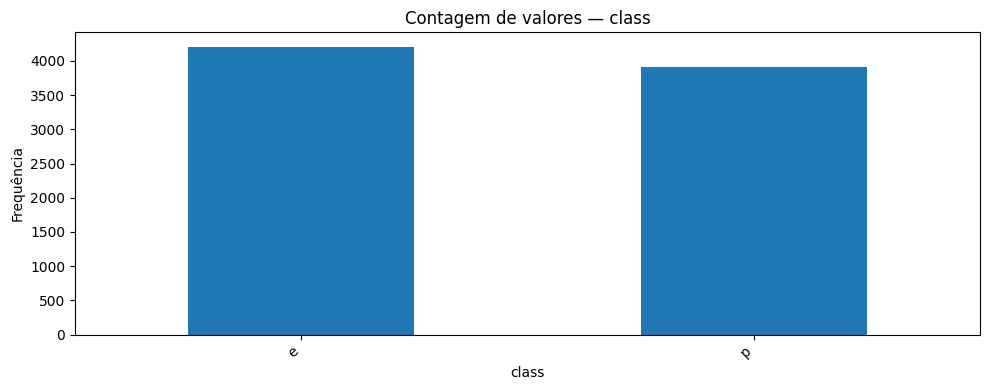

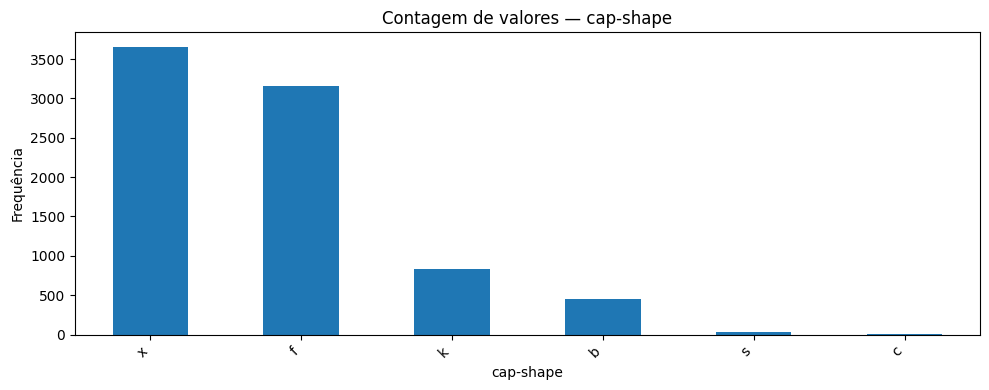

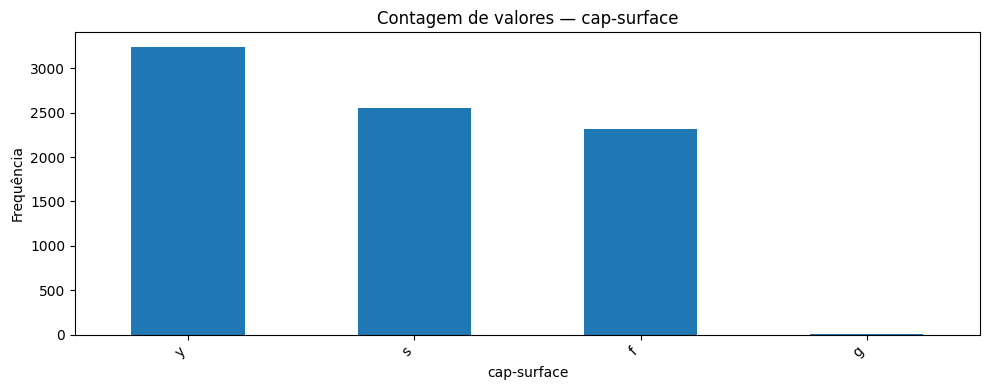

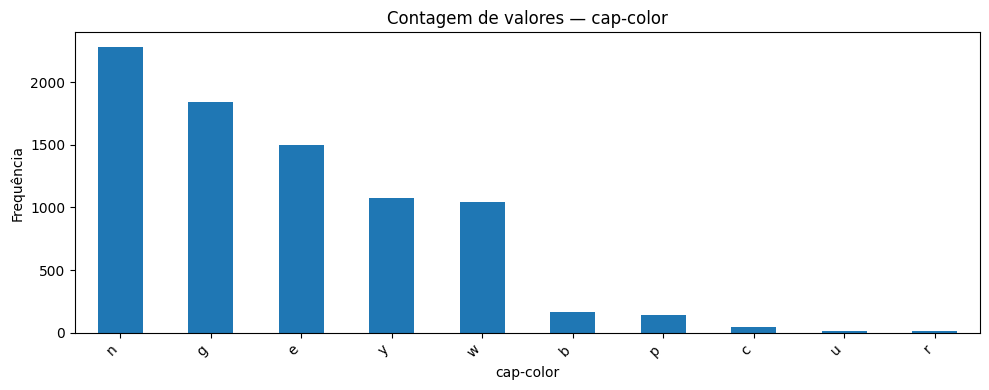

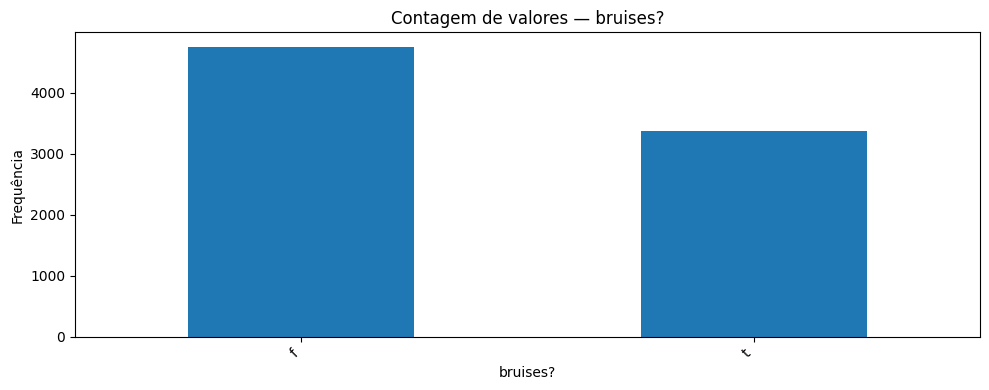

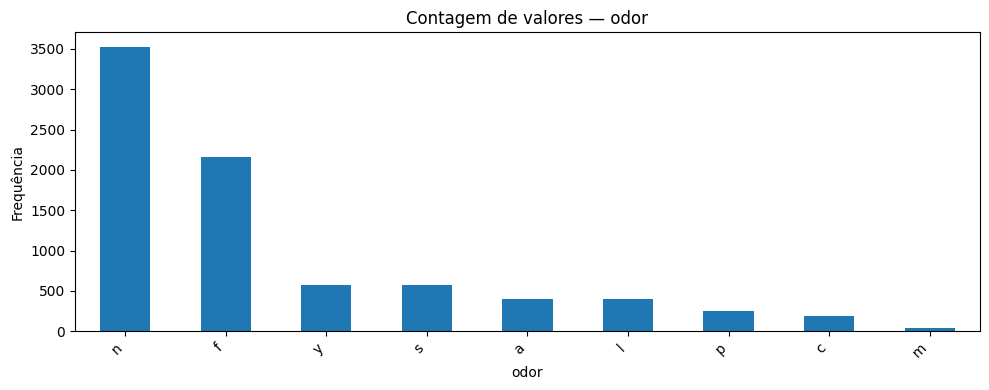

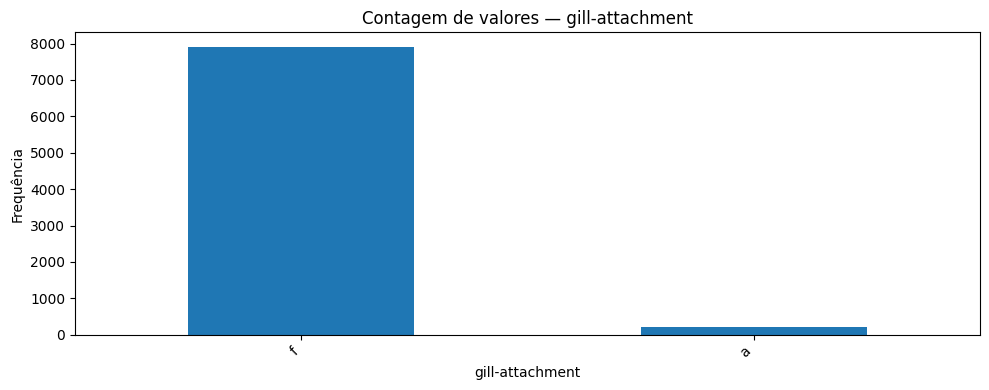

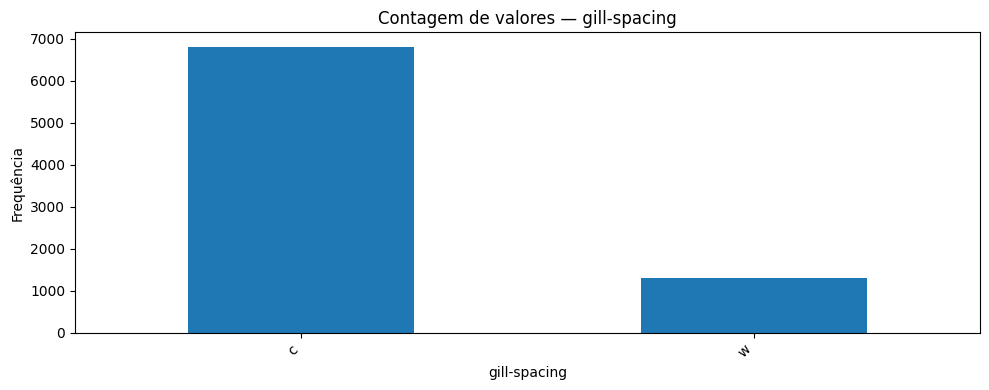

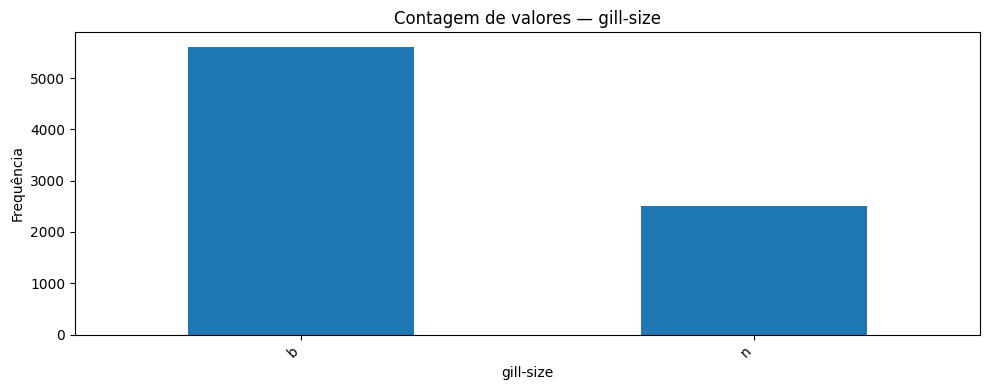

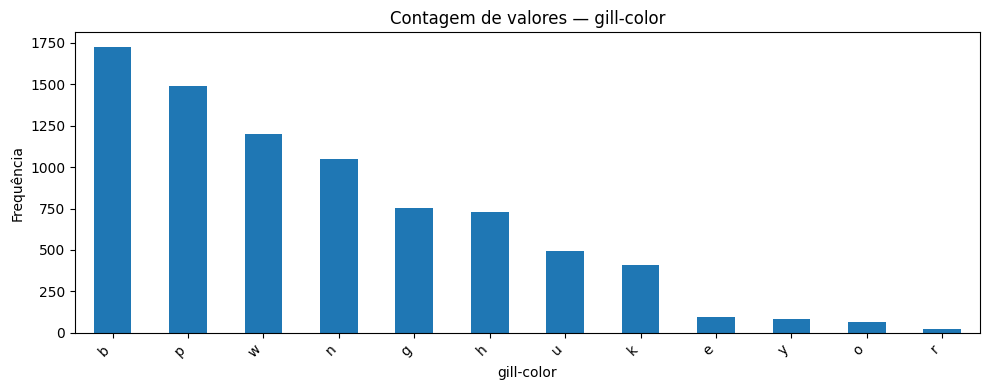

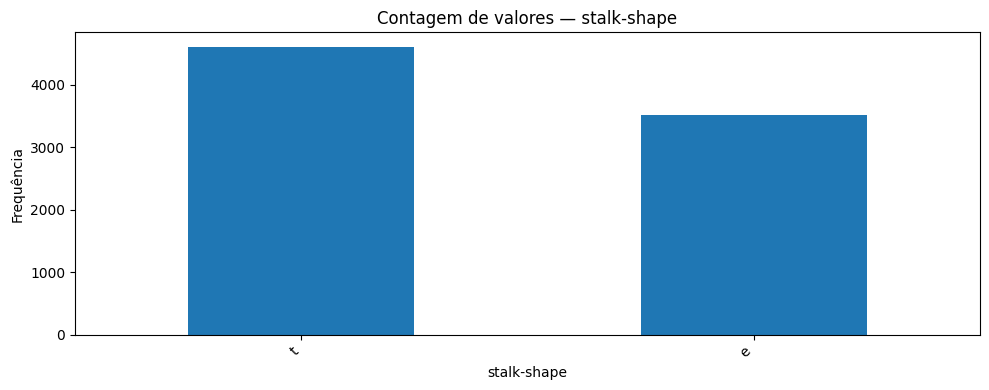

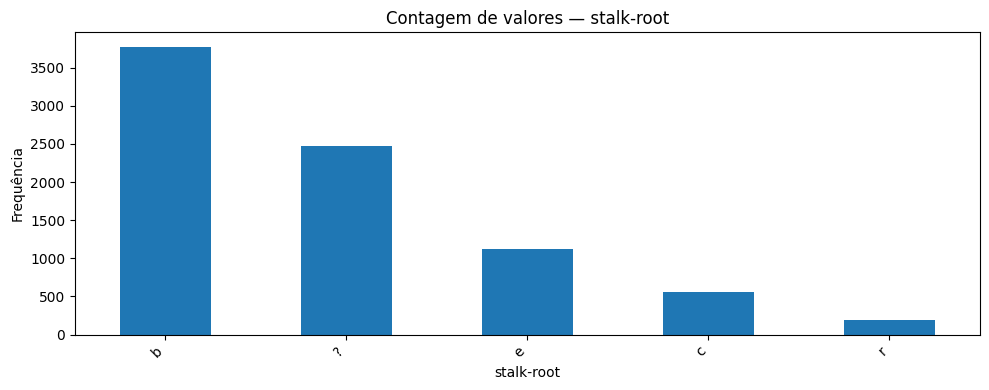

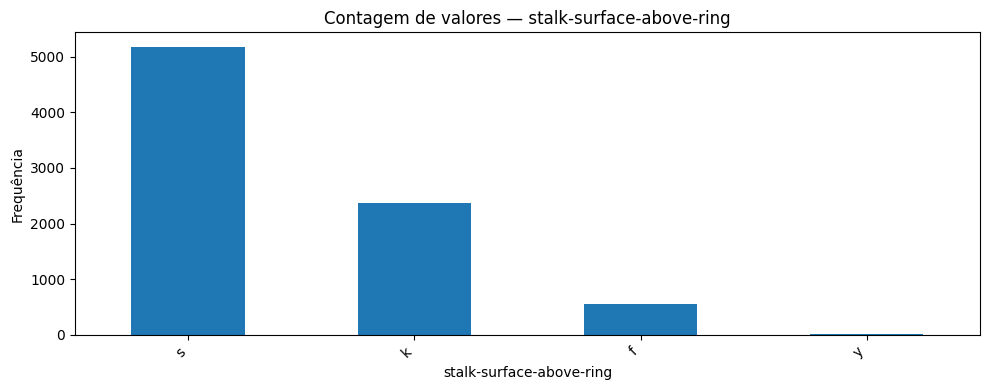

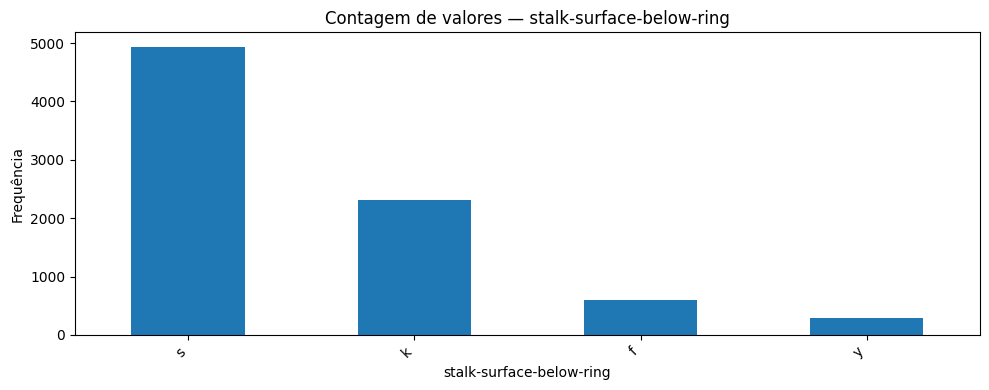

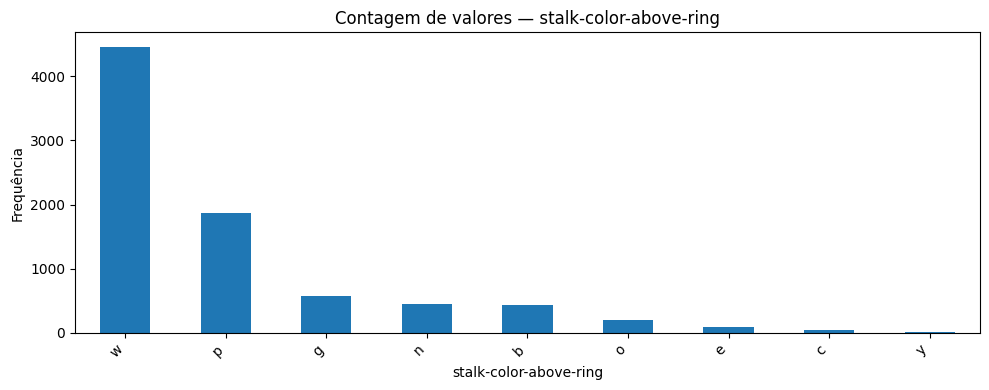

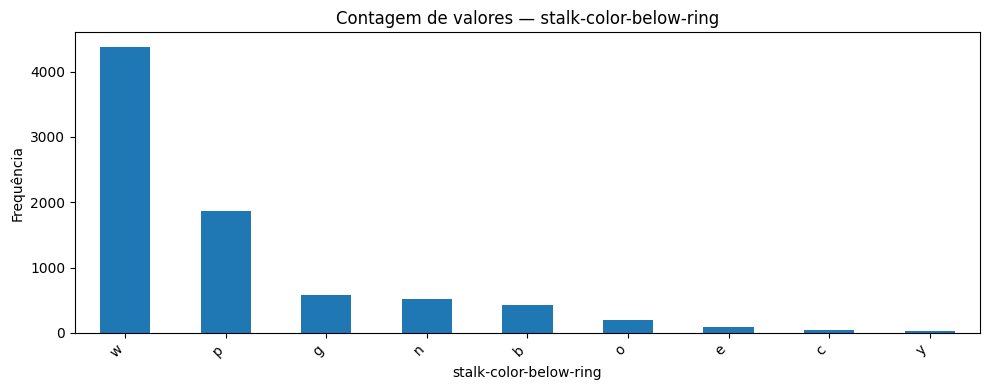

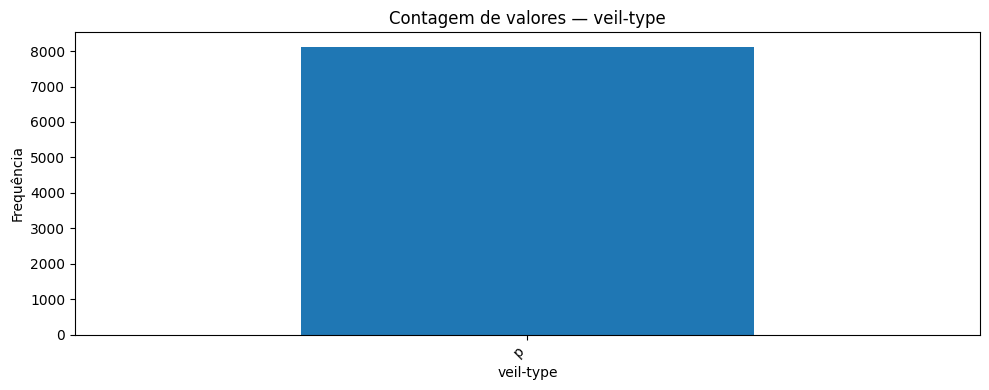

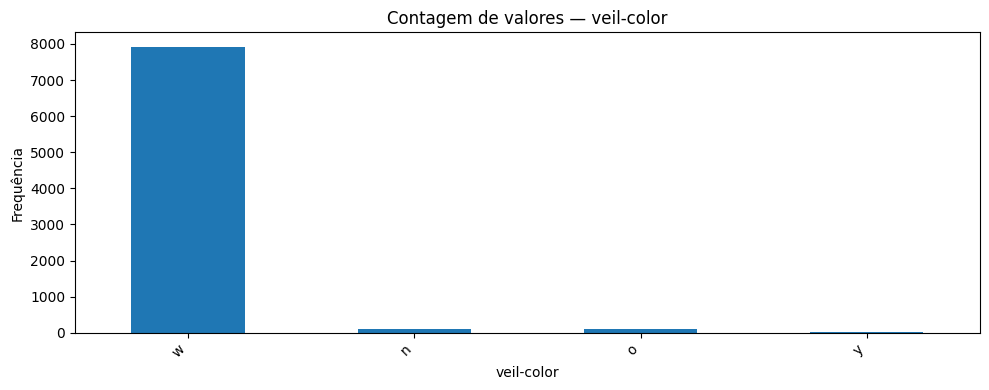

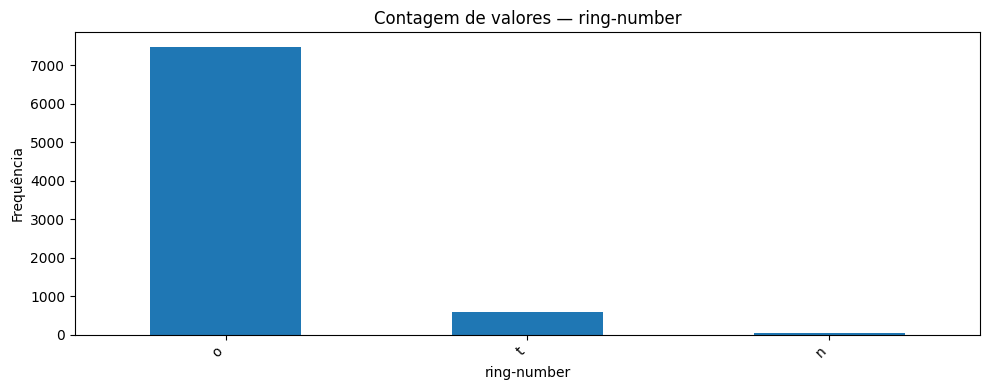

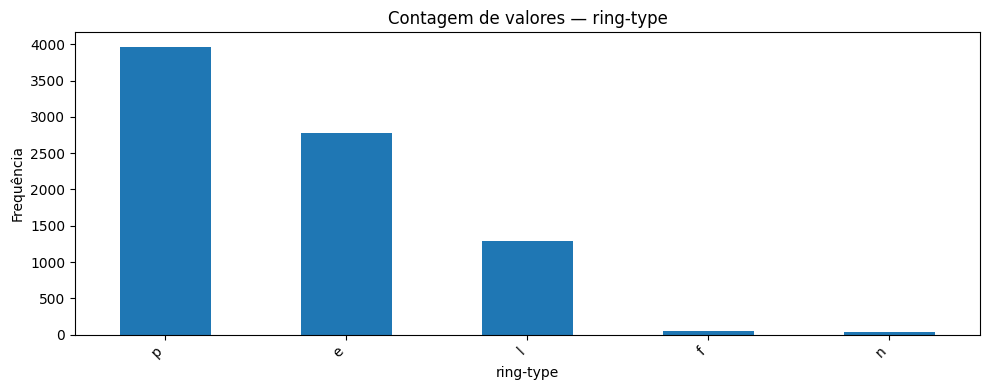

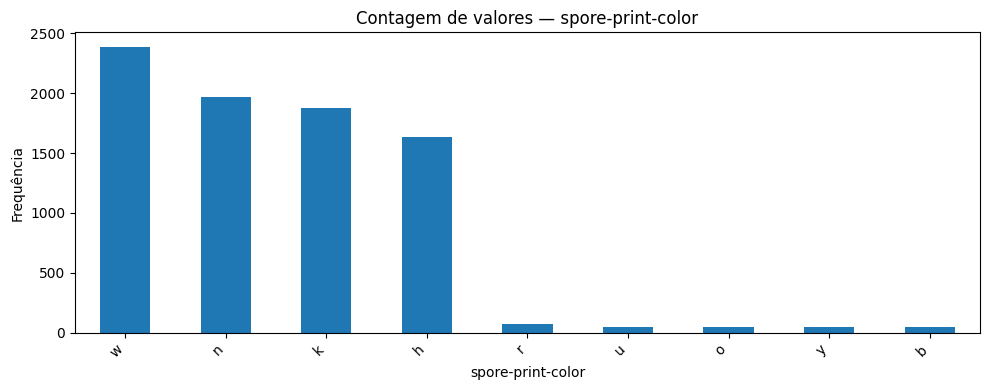

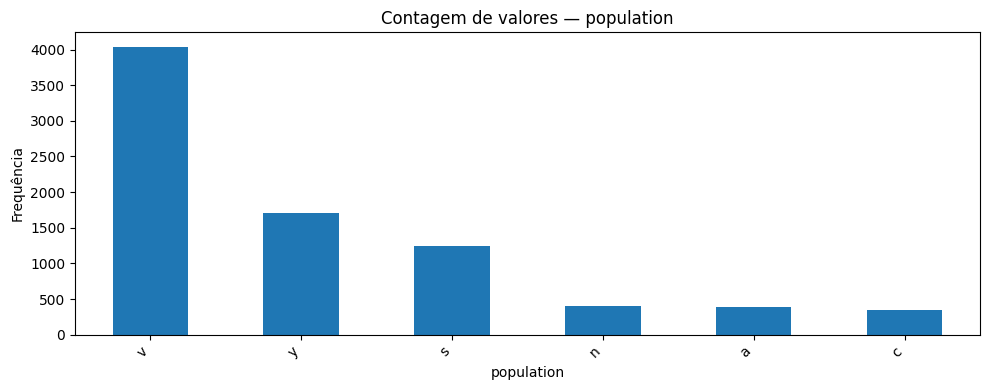

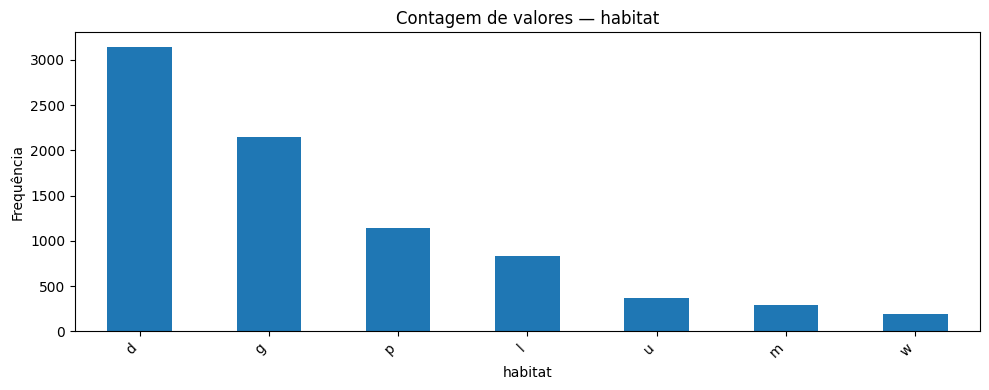

In [6]:
# Visualizações exploratórias básicas
# O grupo deve adaptar as colunas às características do dataset.


def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 20) -> None:
    plt.figure(figsize=(10, 4))
    df[coluna].value_counts(dropna=False).head(top_n).plot(kind="bar")
    plt.title(f"Contagem de valores — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

for name in df.columns:
    plot_contagem_categorica(df, name)


## 2.2 Análise visual — interpretação

**1. Concentração e Desbalanceamento de Valores:**
- Atributos Dominantes: Variáveis como veil-color, ring-number, gill-attachment e veil-type apresentam um desbalanceamento extremo, onde uma única categoria detém quase a totalidade das instâncias. O caso mais crítico é o veil-type, que possui variância zero (100% de valores 'p'), tornando-o irrelevante para a mineração,
- Concentração Multimodal: Em spore-print-color e cap-color, há uma concentração clara em 4 ou 5 categorias principais (como branco e marrom), enquanto as demais cores são raras. Isso indica que as regras com maior Suporte virão dessas combinações cromáticas majoritárias.

**2. Categorias Raras e Riscos (Monitoramento e Avaliação):**
Observamos \"caudas longas\" em diversos atributos, como as cores de chapéu u (roxo) e r (verde), ou o habitat w (resíduos).

- Risco Identificado: Categorias muito raras podem gerar regras com Confiança de 100% de forma espúria (devido ao baixo número de amostras). Para mitigar isso, conforme nossa diretriz de Monitoramento, não confiaremos apenas na confiança, utilizando o Lift para validar se a associação é estatisticamente superior ao acaso.

**3. Padrões de Co-ocorrência Potenciais (Explicabilidade):**

Os atributos de textura, como stalk-surface-above-ring e stalk-surface-below-ring, apresentam distribuições muito similares, sugerindo uma forte correlação entre as partes do caule.
O atributo bruises (manchas) divide o dataset de forma equilibrada, o que é um excelente sinal para a Explicabilidade, pois é uma característica binária de fácil observação que pode servir como um divisor mestre nos antecedentes das regras.

**4. Tratamento de Incertezas:**
O atributo stalk-root possui uma categoria missing expressiva (2.480 ocorrências). A visualização confirma que esta não é uma falha pontual, mas uma característica estrutural de uma grande fatia das amostras. Tratá-la como uma categoria válida, e não como erro, preserva a integridade biológica do modelo.

In [ ]:
# Detecção simples de outliers em variáveis numéricas usando IQR
# Esta função é um exemplo. O grupo deve avaliar se o critério faz sentido para cada atributo.

def detectar_outliers_iqr(df: pd.DataFrame, coluna: str) -> pd.DataFrame:
    serie = df[coluna].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

    print(f"Coluna: {coluna}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Limite inferior: {limite_inferior}")
    print(f"Limite superior: {limite_superior}")
    print(f"Número de outliers: {len(outliers)}")

    return outliers

# Exemplo de uso:
# outliers = detectar_outliers_iqr(df, "[COLUNA_NUMERICA]")
# display(outliers.head())


Contagem de valores ausentes em stalk-root

In [7]:
(df['stalk-root']=='?').sum()

np.int64(2480)

In [8]:
#verificando duplicats
df.duplicated().sum()

np.int64(0)

## 2.3 Problemas de qualidade dos dados

| Problema identificado | Evidência | Decisão tomada | Justificativa |
|---|---|---|---|
| Valores ausentes em `stalk-root` | stalk-root tem 2.480 ocorrências de ? no gráfico de barras. | MANTER | O valor não é um erro de preenchimento, mas uma característica biológica ou limitação de coleta comum em micologia. Removê-lo causaria perda de 30% do dataset.  |
| Duplicatas |  df.duplicated().sum() (Verificar valor no notebook) | NÃO SE APLICA | O dataset não apresenta registros idênticos, garantindo que cada transação representa uma observação biológica distinta. |
| Outliers (Dados Categóricos) | Gráficos de habitat, cap-shape e cap-color com barras pequenas. | MANTER E MONITORAR | Em dados categóricos, \"outliers\" são categorias raras. Manteremos todas para não ignorar espécimes venenosos raros. |
| Atributos de Variância Zero | Gráfico de veil-type com 100% de frequência em uma única categoria. | REMOVER | Atributos constantes não possuem poder discriminatório. |
| Baixa Variabilidade | Gráficos de veil-color e ring-number (predomínio > 90% de um valor). | MANTER | Embora desbalanceados, possuem variação mínima que pode ser crucial para regras de exceção ligadas à segurança. |

### Observação sobre responsabilidade

As decisões tomadas nesta etapa de saneamento e preparação de dados refletem diretamente o compromisso com as diretrizes de **Segurança** e **Transparência e Explicabilidade** estabelecidas para o projeto:

* **Tratamento de `stalk-root` (`?`) e Segurança:** A escolha de manter os valores ausentes codificados (seja tratando a interrogação como uma categoria legítima de "não identificado" ou aplicando uma técnica de imputação conservadora) cumpre a diretriz de **Segurança**. Eliminar as 2.480 linhas afetadas reduziria drasticamente o volume do dataset, comprometendo a capacidade do modelo de generalizar sobre espécimes que exibem essa ausência morfológica na natureza, o que poderia elevar o risco de falsos negativos catastróficos.
* **Manutenção de categorias raras e Robustez:** Não descartar as categorias de baixa frequência em variáveis como `cap-color` e `habitat` ampara-se no princípio de tolerância zero a falhas críticas. Se o modelo descartasse classes minoritárias para simplificar sua estrutura estatística global, ele se tornaria cego para variações raras de cogumelos venenosos. Para garantir a **Robustez**, o classificador precisa aprender as fronteiras dessas exceções biológicas.
* **Remoção de `veil-type` e Explicabilidade:** A exclusão de atributos com variância zero limpa o ruído estrutural dos dados, forçando algoritmos como as Árvores de Decisão a se concentrarem apenas em variáveis que de fato fragmentam o espaço multidimensional em regras biológicas lógicas e auditáveis. Isso evita a indução de caminhos redundantes ou nós espúrios na árvore, tornando o modelo final significativamente mais enxuto, transparente e passível de validação por especialistas humanos.

In [ ]:
# 2.4 Preparação dos dados adaptada (Fase 2)

def preparar_dados_basico(df: pd.DataFrame) -> pd.DataFrame:
    df_prep = df.copy()

    # 1. Remover duplicatas exatas 
    # (Boa prática, mesmo que o resultado atual seja 0)
    df_prep = df_prep.drop_duplicates()

    # 2. Remover colunas sem variância (Atributos constantes)
    # Como vimos nos gráficos, 'veil-type' tem 100% de valores 'p' e deve sair.
    colunas_remover = ["veil-type"]
    df_prep = df_prep.drop(columns=[c for c in colunas_remover if c in df_prep.columns])

    # 3. Tratamento de nulos
    # No nosso caso, o 'stalk-root' já tem o valor 'missing' que criamos no carregamento.
    # Não faremos imputações extras (como moda) para não distorcer os padrões reais.
    
    # One hot encoding
    df_prep = pd.get_dummies(df_prep, columns=df.columns, dtype=int)
    return df_prep

df_prep = preparar_dados_basico(df)

print(f"Dimensões originais: {df.shape}")
print(f"Dimensões após preparação: {df_prep.shape}")
display(df_prep.head())

Dimensões originais: (8124, 23)
Dimensões após preparação: (8124, 119)


,class_e,class_p,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0,1,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0,1,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
4,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0


## 2.4 Justificativa da preparação dos dados


A preparação dos dados foi guiada pela necessidade de manter a integridade biológica do dataset, garantindo que a simplificação estatística não gerasse pontos cegos na identificação de riscos.

**1. Remoção de Colunas:** Foi removida apenas a coluna `veil-type`. A justificativa é técnica: por apresentar variância zero (todas as amostras possuem o mesmo valor), ela não possui poder discriminatório para algoritmos de associação, sendo apenas ruído computacional.

**2. Tratamento de Valores Ausentes:** Em conformidade com a análise de qualidade, os valores `?` do atributo `stalk-root` foram mantidos. Decidimos não realizar imputação (como preencher com a moda), pois em um contexto de segurança, inventar um valor para a raiz do cogumelo poderia gerar regras falsas e perigosas.

**3. Tratamento de Variáveis Categóricas:** O dataset é integralmente categórico. Por tanto, decidimos fazer one-hot encoding pois a tarefa é classificação, e será mais fácil assim do que tratar como texto.

**4. Normalização, Discretização e Outliers:** Não houve necessidade de normalização ou discretização, dada a ausência de variáveis numéricas. Da mesma forma, a remoção de outliers pelo método IQR foi descartada por ser incompatível com dados nominais. Categorias raras foram mantidas para preservar a diversidade biológica.

**6. Relação com as Diretrizes:**
* **Explicabilidade:** Ao fazer one-hot encoding, preservamos a semântica das colunas, então o modelo continuará explicável.
* **Segurança:** A decisão de manter o dado "?" ao invés de imputar garante a segurança, porque não estamos criando correlações espúrias.

## 2.5 Interações com LLM — Data Understanding & Data Preparation

### Subtarefa comparável

Nesta etapa, as duas trilhas devem receber a mesma subtarefa geral.

**Subtarefa escolhida:** propor estratégias de limpeza, transformação e preparação dos dados para a tarefa de mineração

---

### Trilha A — baseline

**Modelo utilizado:** Gemini 3.5 Flash
**Data de acesso:** 13/06/2026   
**Link da conversa:** https://gemini.google.com/share/99126ff13691

#### Prompt principal — baseline

```text
Tenho o "Mushroom Dataset" com as seguintes colunas e mapeamentos categóricos:
- class (alvo): edible=e, poisonous=p
- cap-shape: bell=b, conical=c, convex=x, flat=f, knobbed=k, sunken=s
- cap-surface: fibrous=f, grooves=g, scaly=y, smooth=s
- cap-color: brown=n, buff=b, cinnamon=c, gray=g, green=r, pink=p, purple=u, red=e, white=w, yellow=y
- bruises?: bruises=t, no=f
- odor: almond=a, anise=l, creosote=c, fishy=y, foul=f, musty=m, none=n, pungent=p, spicy=s
- gill-attachment: attached=a, descending=d, free=f, notched=n
- gill-spacing: close=c, crowded=w, distant=d
- gill-size: broad=b, narrow=n
- gill-color: black=k, brown=n, buff=b, chocolate=h, gray=g, green=r, orange=o, pink=p, purple=u, red=e, white=w, yellow=y
- stalk-shape: enlarging=e, tapering=t
- stalk-root: bulbous=b, club=c, cup=u, equal=e, rhizomorphs=z, rooted=r, missing=?
- stalk-surface-above-ring: fibrous=f, scaly=y, silky=k, smooth=s
- stalk-surface-below-ring: fibrous=f, scaly=y, silky=k, smooth=s
- stalk-color-above-ring: brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y
- stalk-color-below-ring: brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y
- veil-type: partial=p, universal=u
- veil-color: brown=n, orange=o, white=w, yellow=y
- ring-number: none=n, one=o, two=t
- ring-type: cobwebby=c, evanescent=e, flaring=f, large=l, none=n, pendant=p, sheathing=s, zone=z
- spore-print-color: black=k, brown=n, buff=b, chocolate=h, green=r, orange=o, purple=u, white=w, yellow=y
- population: abundant=a, clustered=c, numerous=n, scattered=s, several=v, solitary=y
- habitat: grasses=g, leaves=l, meadows=m, paths=p, urban=u, waste=w, woods=d

A tarefa de mineração de dados é uma classificação supervisionada para prever se um cogumelo é comestível ou venenoso (coluna 'class') com base nas suas características morfológicas.

Sugira uma estratégia de Data Understanding e Data Preparation para preparar os dados para essa tarefa.
```

#### Síntese da resposta da LLM

A Trilha A apresenta uma abordagem técnica convencional e estruturada baseada no framework CRISP-DM para um dataset puramente categórico. Na etapa de **Data Understanding**, foca em análises estatísticas tradicionais: validação do equilíbrio natural das classes (~52% comestíveis e 48% venenosos), identificação de baixa variância (como a coluna `veil-type`, que possui apenas um valor) e cálculo de associação categórica usando o V de Cramér ou Informação Mútua (destacando a forte relação entre `odor` e a variável alvo). Para o **Data Preparation**, a estratégia adota passos lineares de engenharia de software: eliminação de colunas redundantes; tratamento do caractere `?` na coluna `stalk-root` como uma nova categoria ("Desconhecido") para evitar a perda de 30% do dataset; aplicação de *One-Hot Encoding* para modelos lineares ou *Ordinal Encoding* para modelos de árvore; e a execução de um split de treino/teste estritamente estratificado. O foco principal é a eficiência algorítmica, a modelagem matemática correta e a prevenção de vazamento de dados (*data leakage*).

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini 3.5 Flash
**Data de acesso:** 13/06/2026  
**Link da conversa:** https://gemini.google.com/share/d153563cc568

#### Prompt principal — guiado

```text
Tenho o "Mushroom Dataset" com as seguintes colunas e mapeamentos categóricos:
- class (alvo): edible=e, poisonous=p
- cap-shape: bell=b, conical=c, convex=x, flat=f, knobbed=k, sunken=s
- cap-surface: fibrous=f, grooves=g, scaly=y, smooth=s
- cap-color: brown=n, buff=b, cinnamon=c, gray=g, green=r, pink=p, purple=u, red=e, white=w, yellow=y
- bruises?: bruises=t, no=f
- odor: almond=a, anise=l, creosote=c, fishy=y, foul=f, musty=m, none=n, pungent=p, spicy=s
- gill-attachment: attached=a, descending=d, free=f, notched=n
- gill-spacing: close=c, crowded=w, distant=d
- gill-size: broad=b, narrow=n
- gill-color: black=k, brown=n, buff=b, chocolate=h, gray=g, green=r, orange=o, pink=p, purple=u, red=e, white=w, yellow=y
- stalk-shape: enlarging=e, tapering=t
- stalk-root: bulbous=b, club=c, cup=u, equal=e, rhizomorphs=z, rooted=r, missing=?
- stalk-surface-above-ring: fibrous=f, scaly=y, silky=k, smooth=s
- stalk-surface-below-ring: fibrous=f, scaly=y, silky=k, smooth=s
- stalk-color-above-ring: brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y
- stalk-color-below-ring: brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y
- veil-type: partial=p, universal=u
- veil-color: brown=n, orange=o, white=w, yellow=y
- ring-number: none=n, one=o, two=t
- ring-type: cobwebby=c, evanescent=e, flaring=f, large=l, none=n, pendant=p, sheathing=s, zone=z
- spore-print-color: black=k, brown=n, buff=b, chocolate=h, green=r, orange=o, purple=u, white=w, yellow=y
- population: abundant=a, clustered=c, numerous=n, scattered=s, several=v, solitary=y
- habitat: grasses=g, leaves=l, meadows=m, paths=p, urban=u, waste=w, woods=d

A tarefa de mineração de dados é uma classificação supervisionada para prever se um cogumelo é comestível ou venenoso (coluna 'class') com base nas suas características morfológicas.

Sugira uma estratégia de Data Understanding e Data Preparation para preparar os dados para essa tarefa.

Considere explicitamente as diretrizes de IA Responsável:
1. Segurança (considerando o risco extremo de falsos negativos em decisões de envenenamento e a presença de dados faltantes como o "?" na coluna 'stalk-root').
2. Transparência e Explicabilidade (considerando que o modelo gerado precisa ser interpretável por biólogos ou especialistas do domínio).

Ao sugerir a preparação, indique:
- possíveis atributos sensíveis ou de alto impacto para a tomada de decisão crítica, se houver;
- riscos de viés ou perda crítica de informação (especialmente ao lidar com o "?" e categorias raras);
- decisões estruturais de pré-processamento que devem ser rigorosamente documentadas;
- transformações necessárias (como o tipo de encoding para variáveis puramente categóricas);
- limitações da abordagem de preparação e trade-offs assumidos.
```

#### Síntese da resposta da LLM

A Trilha B reorienta os mesmos processos sob a ótica de IA Responsável, colocando a segurança humana e a interpretabilidade biológica no centro das decisões. No **Data Understanding**, os atributos não são avaliados apenas por sua capacidade preditiva matemática, mas pelo risco operacional (como a fragilidade de depender do `odor` se o usuário tiver anosmia) e pelo impacto de se negligenciar categorias raras (que podem representar espécies letais e não "ruídos" estatísticos). No **Data Preparation**, o tratamento de dados faltantes (`?`) e raros é guiado pelo princípio da robustez e tolerância zero a falhas críticas, preparando o cenário para a otimização do *Recall* (minimizando falsos negativos fatais). Para atender à diretriz de explicabilidade, propõe-se um mapeamento reverso das siglas para termos biológicos completos antes do encoding, a rejeição a métodos que inventam ordens artificiais (como *Target Encoding*), o uso ponderado de *One-Hot Encoding* para gerar regras de decisão legíveis por humanos e o uso de *Ordinal Encoding* restrito a grandezas reais (como `ring-number`). Conclui documentando rigorosamente o *data lineage* e assumindo explicitamente os *trade-offs* de esparsidade dimensional e as limitações de um modelo puramente morfológico diante de riscos químicos reais.


## 2.6 Comparação crítica — Data Understanding & Preparation

| Aspecto | Trilha A — baseline | Trilha B — guiada | Decisão do grupo |
|---|---|---|---|
| **Tratamento de nulos** | Sugeriu mapear o `?` em `stalk-root` e decidir entre manter como nova categoria, imputar pela moda ou remover as linhas. | Exigiu a manutenção do `?` como uma nova categoria biológica legítima ("unknown"), proibindo a imputação pela moda para evitar riscos à segurança. | **ACEITAR TRILHA B**: Manteremos o `?` como categoria mapeada para não perder 30% do dataset e nem distorcer os padrões de toxicidade. |
| **Tratamento de outliers** | Não aprofundou em dados categóricos; focou na lógica padrão de que o dataset é limpo e equilibrado. | Identificou que outliers categóricos são classes raras (ex: formatos/cores incomuns) e exigiu sua manutenção para não ignorar ameaças letais raras. | **ACEITAR TRILHA B**: Manteremos todas as categorias minoritárias com base no princípio de segurança e monitoramento biológico. |
| **Atributos sensíveis** | Não identificou ou mencionou a existência de atributos sensíveis (foco puramente estrutural). | Explicou que não há dados sensíveis clássicos (LGPD), mas que o `odor` é um atributo de alto impacto crítico cujo mau uso gera riscos à segurança. | **ACEITAR TRILHA B**: Validamos que não há atributos protegidos por lei, mas trataremos variáveis dominantes como pontos de atenção crítica. |
| **Codificação de variáveis** | Propôs de forma genérica *One-Hot Encoding* para modelos lineares/distância e *Ordinal Encoding* para modelos de árvore. | Recomendou *One-Hot Encoding* para garantir explicabilidade em regras textuais e *Ordinal Encoding* exclusivamente para variáveis com ordem real (`ring-number`). | **CORRIGIR**: Adotamos *One-Hot Encoding* amplo visando a interpretabilidade biológica das regras, mas rejeitamos *Ordinal* arbitrário em variáveis puramente nominais. Sobretudo porque não necessariamente 'none' deveria ser menor que 'one' |
| **Redução de dimensionalidade** | Identificou corretamente a variância zero no atributo `veil-type` sugerindo sua exclusão imediata. | Também sugeriu a exclusão de `veil-type` sob a justificativa de limpar o ruído para otimizar a explicabilidade de árvores de decisão. | **ACEITAR AMBAS**: O atributo `veil-type` foi removido por possuir variância zero, limpando o formato estrutural dos dados. |
| **Justificativa técnica** | Centrada na eficiência do pipeline de software (CRISP-DM), na compatibilidade matemática com algoritmos e na prevenção de *data leakage*. | Centrada na mitigação de Falsos Negativos (minimização de envenenamento), transparência para especialistas e preservação de semântica biológica. | **ACEITAR TRILHA B**: Nossa justificativa metodológica prioriza a robustez e a confiabilidade do modelo devido à natureza crítica do problema. |
| **Riscos e limitações** | Limitou-se a alertar sobre a armadilha da multicolinearidade e o mal da dimensionalidade ao usar *One-Hot Encoding*. | Alertou sobre os riscos de esparsidade dos dados, mutações biológicas não mapeadas no histórico e a limitação de usar apenas morfologia. | **ACEITAR TRILHA B**: Incorporamos os alertas sobre os limites de um modelo puramente morfológico em comparação a testes químicos. |

### Análise crítica

A comparação entre as duas abordagens revelou o impacto imediato da engenharia de prompts baseada em diretrizes de responsabilidade para tarefas críticas de Ciência de Dados:

* **O que a LLM sugeriu corretamente:** Ambas as trilhas identificaram com precisão a inconsistência de variância zero no atributo `veil-type`, recomendando sua exclusão. Também diagnosticaram corretamente que o caractere `?` na coluna `stalk-root` operava como um dado ausente mascarado, mapeando adequadamente o risco de perda volumétrica caso essas linhas fossem deletadas.
* **O que estava incompleto:** A Trilha A falhou ao tratar o tratamento de nulos e encodings como meras opções de livre escolha do programador (sugerindo imputação por moda ou remoção), sem correlacionar essas escolhas com as consequências práticas no domínio do problema. Ela também foi superficial na análise de outliers por focar em uma visão estritamente numérica.
* **O que estava tecnicamente errado:** A Trilha A sugeriu que, para modelos de árvores, poderiamos aplicar *Ordinal Encoding* (Label Encoding) nas variáveis preditoras de forma generalizada. Embora algoritmos baseados em árvores lidem com inteiros, aplicar uma escala sequencial ($0, 1, 2...$) em atributos puramente nominais e sem hierarquia (como `cap-color`) pode induzir o modelo a interpretar distâncias inexistentes na biologia, prejudicando a explicabilidade das regras.
* **O que foi aceito:** Aceitamos a visão da Trilha B a respeito do tratamento do `stalk-root` (manter como categoria "Desconhecido") e da preservação rigorosa das categorias de baixa frequência (outliers categóricos), visto que a eliminação de dados minoritários poderia cegar o modelo para cogumelos venenosos raros.
* **O que foi rejeitado:** Rejeitamos a sugestão da Trilha A de imputar dados ausentes pela moda ou cogitar a exclusão de registros. No contexto de segurança biológica, fabricar dados sintéticos ou mascarar desconhecimentos com a categoria mais frequente reduz drasticamente a confiabilidade do sistema.
* **O que foi corrigido pelo grupo:** Ajustamos a estratégia final de *encoding*. Para garantir que o modelo final atenda à diretriz de **Explicabilidade**, padronizamos a aplicação de *One-Hot Encoding* para as preditoras nominais combinada com o mapeamento textual completo de suas siglas originais. O uso de codificação ordinal ficou restrito unicamente à coluna `ring-number`, que possui uma ordem quantitativa natural (zero, um ou dois anéis).


# 3. Modeling

Nesta seção, o grupo deve documentar a modelagem proposta com apoio da LLM.

Para o TP de padrões frequentes, a modelagem pode envolver, por exemplo:

- Apriori;
- FP-Growth;
- Eclat;
- regras de associação.

Para outros TPs, substituir pelos algoritmos pertinentes, como algoritmos de agrupamento ou classificação.

O foco da Fase 2 é comparar criticamente as soluções sugeridas pela LLM nas duas trilhas e, quando possível, executar testes preliminares para verificar a viabilidade das sugestões.


## 3.1 Interações com LLM — Modeling

### Subtarefa comparável

**Subtarefa escolhida:** [EXEMPLO: propor algoritmos, parâmetros, métricas e estratégia de avaliação para a tarefa]

---

### Trilha A — baseline

**Modelo utilizado:** [INSERIR MODELO]  
**Data de acesso:** [INSERIR DATA]  
**Link da conversa:** [INSERIR LINK DA CONVERSA]

#### Prompt principal — baseline

```text
[INSERIR PROMPT BASELINE]

Exemplo:
Com base no dataset [NOME] e na tarefa [TAREFA], proponha uma estratégia de modelagem.
Indique algoritmos, parâmetros iniciais, métricas de avaliação e como comparar resultados.
```

#### Síntese da resposta da LLM

[INSERIR SÍNTESE]

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** [INSERIR MODELO]  
**Data de acesso:** [INSERIR DATA]  
**Link da conversa:** [INSERIR LINK DA CONVERSA]

#### Prompt principal — guiado

```text
[INSERIR PROMPT GUIADO]

Exemplo:
Com base no dataset [NOME] e na tarefa [TAREFA], proponha uma estratégia de modelagem.

Considere explicitamente as diretrizes:
1. [DIRETRIZ 1]
2. [DIRETRIZ 2]

Na resposta, indique:
- algoritmos adequados;
- parâmetros iniciais;
- métricas de avaliação;
- riscos metodológicos;
- impacto das diretrizes nas escolhas;
- trade-offs entre desempenho, interpretabilidade, custo computacional e qualidade da solução.
```

#### Síntese da resposta da LLM

[INSERIR SÍNTESE]


## 3.2 Comparação das soluções sugeridas pela LLM

| Elemento | Trilha A — baseline | Trilha B — guiada | Diferença concreta? | Comentário do grupo |
|---|---|---|---|---|
| Algoritmos sugeridos | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Parâmetros sugeridos | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Métricas sugeridas | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Preparação exigida | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Interpretabilidade | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Custo computacional | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Riscos ou limitações | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Aderência às diretrizes | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |

### Síntese

[INSERIR ANÁLISE COMPARATIVA]

A comparação deve destacar evidências, não impressões vagas.


## 3.3 Template de modelagem para padrões frequentes

Use esta subseção se o TP atual envolver mineração de padrões frequentes. Caso o TP atual seja de agrupamento ou classificação, esta subseção pode ser removida ou mantida como referência não executada.

> **Atenção:** suporte, confiança e lift devem ser interpretados no contexto do dataset. Valores de suporte muito baixos podem gerar muitas regras pouco úteis; valores muito altos podem ocultar padrões relevantes.


In [ ]:
# Exemplo de preparação para mineração de padrões frequentes
# Use esta célula apenas se o TP atual for de padrões frequentes.
# Para classificação ou agrupamento, substituir por uma preparação adequada.

def gerar_transacoes_de_coluna(df: pd.DataFrame, coluna: str, separador: str = ",") -> list:
    # Gera uma lista de transações a partir de uma coluna textual.
    # Exemplo: "leite, pão, manteiga" -> ["leite", "pão", "manteiga"]
    transacoes = []

    for valor in df[coluna].dropna():
        itens = [
            item.strip().lower()
            for item in str(valor).split(separador)
            if item.strip()
        ]

        if len(itens) > 0:
            transacoes.append(itens)

    return transacoes

# Exemplo de uso:
# transacoes = gerar_transacoes_de_coluna(df_prep, TRANSACTION_COLUMN)
# print(f"Número de transações: {len(transacoes)}")
# print(transacoes[:5])


In [ ]:
# Exemplo de execução de Apriori e FP-Growth com mlxtend
# Esta célula é semi-funcional e depende da instalação da biblioteca mlxtend.
# O grupo deve ajustar suporte, confiança e métrica conforme o problema.

def executar_padroes_frequentes(transacoes, min_support=0.05, min_confidence=0.6):
    try:
        from mlxtend.preprocessing import TransactionEncoder
        from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    except ImportError:
        print("Biblioteca mlxtend não instalada.")
        print("Instale com: pip install mlxtend")
        return None

    te = TransactionEncoder()
    matriz = te.fit(transacoes).transform(transacoes)
    df_transacoes = pd.DataFrame(matriz, columns=te.columns_)

    resultados = {}

    inicio = time.time()
    itemsets_apriori = apriori(
        df_transacoes,
        min_support=min_support,
        use_colnames=True
    )
    regras_apriori = association_rules(
        itemsets_apriori,
        metric="confidence",
        min_threshold=min_confidence
    )
    tempo_apriori = time.time() - inicio

    resultados["Apriori"] = {
        "itemsets": itemsets_apriori,
        "regras": regras_apriori,
        "tempo": tempo_apriori
    }

    inicio = time.time()
    itemsets_fpgrowth = fpgrowth(
        df_transacoes,
        min_support=min_support,
        use_colnames=True
    )
    regras_fpgrowth = association_rules(
        itemsets_fpgrowth,
        metric="confidence",
        min_threshold=min_confidence
    )
    tempo_fpgrowth = time.time() - inicio

    resultados["FP-Growth"] = {
        "itemsets": itemsets_fpgrowth,
        "regras": regras_fpgrowth,
        "tempo": tempo_fpgrowth
    }

    return resultados

# Exemplo de uso:
# resultados = executar_padroes_frequentes(
#     transacoes,
#     min_support=0.05,
#     min_confidence=0.6
# )


In [ ]:
# Resumo dos resultados de mineração de padrões frequentes.
# Esta célula não inventa resultados; ela apenas resume o que foi executado.

def resumir_resultados_padroes(resultados):
    if resultados is None:
        print("Nenhum resultado disponível.")
        return pd.DataFrame()

    linhas = []

    for algoritmo, info in resultados.items():
        itemsets = info["itemsets"]
        regras = info["regras"]

        linhas.append({
            "algoritmo": algoritmo,
            "n_itemsets": len(itemsets),
            "n_regras": len(regras),
            "tempo_segundos": round(info["tempo"], 4),
            "suporte_minimo_observado": itemsets["support"].min() if len(itemsets) > 0 else np.nan,
            "suporte_maximo_observado": itemsets["support"].max() if len(itemsets) > 0 else np.nan,
            "confianca_media": regras["confidence"].mean() if len(regras) > 0 else np.nan,
            "lift_medio": regras["lift"].mean() if len(regras) > 0 and "lift" in regras.columns else np.nan
        })

    return pd.DataFrame(linhas)

# Exemplo de uso:
# resumo_modelagem = resumir_resultados_padroes(resultados)
# display(resumo_modelagem)


In [ ]:
# Exemplo de variação de parâmetros
# Útil para verificar se os resultados são sensíveis às escolhas de suporte e confiança.

def testar_parametros_padroes(transacoes, suportes, confiancas):
    linhas = []

    for sup in suportes:
        for conf in confiancas:
            resultados = executar_padroes_frequentes(
                transacoes,
                min_support=sup,
                min_confidence=conf
            )

            resumo = resumir_resultados_padroes(resultados)

            if not resumo.empty:
                resumo["min_support"] = sup
                resumo["min_confidence"] = conf
                linhas.append(resumo)

    if len(linhas) == 0:
        return pd.DataFrame()

    return pd.concat(linhas, ignore_index=True)

# Exemplo de uso:
# grade_resultados = testar_parametros_padroes(
#     transacoes,
#     suportes=[0.01, 0.03, 0.05],
#     confiancas=[0.5, 0.6, 0.7]
# )
# display(grade_resultados)


## 3.4 Template de modelagem para agrupamento

Use esta subseção se o TP atual envolver agrupamento. Caso contrário, remova ou deixe claro que ela não foi utilizada.

> **Atenção:** em agrupamento, não há rótulo verdadeiro na maioria dos casos. A avaliação deve combinar métricas internas, análise visual quando possível e interpretação substantiva dos grupos.


In [ ]:
# Exemplo genérico para agrupamento com K-Means
# O grupo deve adaptar features, normalização e métricas conforme o dataset.

def preparar_matriz_numerica_para_modelagem(df: pd.DataFrame, colunas=None) -> pd.DataFrame:
    if colunas is None:
        X = df.select_dtypes(include=np.number).copy()
    else:
        X = df[colunas].copy()

    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))

    return X

def executar_kmeans_basico(X: pd.DataFrame, n_clusters=3):
    try:
        from sklearn.preprocessing import StandardScaler
        from sklearn.cluster import KMeans
        from sklearn.metrics import silhouette_score, davies_bouldin_score
    except ImportError:
        print("Biblioteca scikit-learn não instalada.")
        return None

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    modelo = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
    labels = modelo.fit_predict(X_scaled)

    resultados = {
        "modelo": modelo,
        "labels": labels,
        "silhouette": silhouette_score(X_scaled, labels) if n_clusters > 1 else np.nan,
        "davies_bouldin": davies_bouldin_score(X_scaled, labels) if n_clusters > 1 else np.nan,
        "inertia": modelo.inertia_
    }

    return resultados

# Exemplo de uso:
# X = preparar_matriz_numerica_para_modelagem(df_prep)
# resultados_cluster = executar_kmeans_basico(X, n_clusters=3)
# resultados_cluster


## 3.5 Template de modelagem para classificação

Use esta subseção se o TP atual envolver classificação. Caso contrário, remova ou deixe claro que ela não foi utilizada.

> **Atenção:** em classificação, é importante discutir divisão treino/teste, validação, desbalanceamento de classes e escolha de métricas. Acurácia isolada pode ser inadequada em bases desbalanceadas.


In [ ]:
# Exemplo genérico para classificação
# O grupo deve adaptar TARGET_COLUMN, tratamento de categóricas e métricas.

def executar_classificacao_basica(df: pd.DataFrame, target_col: str):
    try:
        from sklearn.model_selection import train_test_split
        from sklearn.pipeline import Pipeline
        from sklearn.compose import ColumnTransformer
        from sklearn.preprocessing import OneHotEncoder, StandardScaler
        from sklearn.impute import SimpleImputer
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.metrics import classification_report, confusion_matrix
    except ImportError:
        print("Biblioteca scikit-learn não instalada.")
        return None

    if target_col not in df.columns:
        raise ValueError(f"Coluna-alvo não encontrada: {target_col}")

    X = df.drop(columns=[target_col])
    y = df[target_col]

    colunas_numericas = X.select_dtypes(include=np.number).columns.tolist()
    colunas_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

    preprocessador = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), colunas_numericas),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), colunas_categoricas)
        ]
    )

    modelo = Pipeline([
        ("preprocessamento", preprocessador),
        ("classificador", RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ))
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y if y.nunique() > 1 else None
    )

    inicio = time.time()
    modelo.fit(X_train, y_train)
    tempo_treino = time.time() - inicio

    y_pred = modelo.predict(X_test)

    print(f"Tempo de treino: {tempo_treino:.4f} segundos")
    print("\nRelatório de classificação:")
    print(classification_report(y_test, y_pred))

    print("\nMatriz de confusão:")
    print(confusion_matrix(y_test, y_pred))

    return {
        "modelo": modelo,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
        "tempo_treino": tempo_treino
    }

# Exemplo de uso:
# resultados_classificacao = executar_classificacao_basica(df_prep, TARGET_COLUMN)


## 3.6 Resultados preliminares da modelagem

[INSERIR RESULTADOS OBTIDOS APÓS EXECUÇÃO DO CÓDIGO]

Inclua tabelas e comentários sobre os resultados relevantes para a tarefa:

### Se a tarefa for padrões frequentes

- número de padrões encontrados;
- número de regras geradas;
- suporte, confiança e lift;
- tempo de execução;
- redundância e interpretabilidade das regras.

### Se a tarefa for agrupamento

- número de clusters;
- métricas internas, como Silhouette e Davies-Bouldin;
- tamanho dos grupos;
- interpretação dos clusters;
- estabilidade com diferentes parâmetros.

### Se a tarefa for classificação

- métricas como acurácia, precisão, revocação, F1-score e matriz de confusão;
- análise de classes minoritárias;
- overfitting ou underfitting;
- interpretabilidade e possíveis vieses.

### Atenção

Não conclua que um algoritmo é “melhor” apenas por uma métrica isolada.

Uma comparação adequada deve considerar:

- qualidade da solução;
- interpretabilidade;
- custo computacional;
- estabilidade;
- adequação ao problema;
- relação com as diretrizes escolhidas.


## 3.7 Análise da aderência às diretrizes

| Diretriz | Evidência na Trilha A | Evidência na Trilha B | A Trilha B melhorou? | Justificativa |
|---|---|---|---|---|
| [DIRETRIZ 1] | [PREENCHER] | [PREENCHER] | [SIM/NÃO/PARCIALMENTE] | [JUSTIFICAR] |
| [DIRETRIZ 2] | [PREENCHER] | [PREENCHER] | [SIM/NÃO/PARCIALMENTE] | [JUSTIFICAR] |

### Discussão

[INSERIR DISCUSSÃO]

A resposta deve ser específica. Exemplos de boa análise:

- “A Trilha B sugeriu registrar parâmetros e versões dos experimentos, o que melhora rastreabilidade.”
- “A Trilha B sugeriu avaliar desempenho por subgrupos, o que é pertinente à diretriz de justiça e viés.”
- “A Trilha B recomendou um algoritmo mais interpretável, mas com possível perda de desempenho.”
- “Apesar de mencionar privacidade, a Trilha B não propôs nenhuma alteração concreta no pipeline.”

Evite frases vagas como:

- “A resposta guiada foi mais responsável.”
- “A LLM considerou melhor as diretrizes.”
- “O resultado foi mais ético.”


# 4. Evaluation

Nesta seção, o grupo deve avaliar criticamente:

1. os resultados preliminares obtidos;
2. a utilidade das sugestões da LLM;
3. os erros e limitações das respostas;
4. as diferenças entre a Trilha A e a Trilha B;
5. os trade-offs observados;
6. a contribuição real das diretrizes de IA responsável.


## 4.1 Análise dos resultados

[INSERIR ANÁLISE DOS RESULTADOS]

A análise deve responder:

- Os padrões, clusters, classificações ou resultados encontrados fazem sentido?
- Eles são relevantes para o problema de negócio?
- Há resultados triviais, redundantes ou pouco úteis?
- O desempenho obtido é adequado?
- As métricas usadas são compatíveis com a tarefa?
- Há limitações nos dados ou na modelagem que afetam a conclusão?

> Se os experimentos não produziram bons resultados, isso também é um resultado válido, desde que seja analisado tecnicamente.


## 4.2 Avaliação das sugestões da LLM

| Sugestão da LLM | Trilha | Decisão do grupo | Justificativa |
|---|---|---|---|
| [SUGESTÃO 1] | Baseline | [ACEITA/REJEITADA/CORRIGIDA] | [JUSTIFICAR] |
| [SUGESTÃO 2] | Guiada | [ACEITA/REJEITADA/CORRIGIDA] | [JUSTIFICAR] |
| [SUGESTÃO 3] | Guiada | [ACEITA/REJEITADA/CORRIGIDA] | [JUSTIFICAR] |

### Erros, omissões ou alucinações identificadas

| Problema | Trilha | Por que é um problema? | Como o grupo corrigiu? |
|---|---|---|---|
| [ERRO/OMISSÃO] | [A/B] | [EXPLICAR] | [EXPLICAR] |
| [ERRO/OMISSÃO] | [A/B] | [EXPLICAR] | [EXPLICAR] |

### Comentário crítico

[INSERIR COMENTÁRIO SOBRE A QUALIDADE DAS RESPOSTAS DA LLM]


## 4.3 Comparação final entre as trilhas

| Critério | Trilha A — baseline | Trilha B — guiada | Avaliação crítica |
|---|---|---|---|
| Utilidade prática | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Correção técnica | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Clareza das justificativas | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Aderência às diretrizes | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Qualidade da modelagem | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Qualidade da avaliação | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Riscos não tratados | [ANALISAR] | [ANALISAR] | [COMPARAR] |

### Conclusão comparativa

[INSERIR CONCLUSÃO]

A conclusão deve indicar se a explicitação das diretrizes:

- produziu mudanças concretas;
- produziu apenas mudanças superficiais;
- não produziu diferença relevante;
- introduziu novos trade-offs;
- ajudou a identificar limitações ou riscos;
- levou o grupo a alterar decisões técnicas.


## 4.4 Trade-offs identificados

| Trade-off | Evidência | Decisão do grupo |
|---|---|---|
| Interpretabilidade × desempenho | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Privacidade × utilidade dos dados | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Custo computacional × qualidade da solução | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Simplicidade × completude da análise | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Justiça/viés × disponibilidade de atributos | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |

### Discussão

[INSERIR DISCUSSÃO SOBRE OS TRADE-OFFS]

Nem todo trade-off estará presente em todo trabalho. O grupo deve discutir apenas os que forem pertinentes ao dataset e à tarefa.


## 4.5 Considerações finais da Fase 2

[INSERIR CONSIDERAÇÕES FINAIS]

A conclusão da Fase 2 deve responder:

1. A LLM ajudou em quais partes do trabalho?
2. Em quais partes a LLM errou ou foi superficial?
3. A Trilha B foi de fato diferente da Trilha A?
4. As diretrizes escolhidas tiveram efeito concreto?
5. Quais sugestões serão levadas para a Fase 3?
6. Quais sugestões serão descartadas?
7. O que ainda precisa ser implementado ou corrigido na versão final?

### Próximos passos para a Fase 3

- [ ] Corrigir limitações identificadas nas respostas da LLM.
- [ ] Consolidar a preparação dos dados.
- [ ] Executar modelagem final.
- [ ] Avaliar resultados de forma mais completa.
- [ ] Integrar análise comparativa baseline × guiada × solução final.
- [ ] Revisar documentação e reprodutibilidade.


# 5. Checklist final da Fase 2

Antes de entregar, verifique se o notebook contém:

- [ ] identificação do grupo;
- [ ] link público do dataset;
- [ ] comprovação de que o dataset atende às restrições mínimas;
- [ ] descrição do problema de negócio;
- [ ] descrição das colunas;
- [ ] diretrizes de IA responsável escolhidas;
- [ ] justificativa das diretrizes;
- [ ] hipótese experimental;
- [ ] Trilha A — baseline;
- [ ] Trilha B — guiada;
- [ ] modelo utilizado em cada trilha;
- [ ] data de acesso em cada trilha;
- [ ] links das conversas;
- [ ] prompts principais;
- [ ] síntese crítica das respostas;
- [ ] comparação entre baseline e guiada;
- [ ] sugestões aceitas, rejeitadas e corrigidas;
- [ ] análise de erros e limitações da LLM;
- [ ] conexão com Business Understanding;
- [ ] conexão com Data Understanding & Preparation;
- [ ] conexão com Modeling;
- [ ] conexão com Evaluation;
- [ ] considerações finais e próximos passos.


# 6. Referências

[INSERIR REFERÊNCIAS USADAS PELO GRUPO]

Exemplos de referências possíveis:

- documentação do dataset;
- materiais da disciplina;
- documentação das bibliotecas usadas;
- referências sobre CRISP-DM;
- referências sobre IA responsável;
- referências sobre algoritmos aplicados.

> As referências devem apoiar decisões técnicas e metodológicas. Não use referências apenas de forma decorativa.


# Apêndice A — Modelo de registro de interações com LLM

Esta seção é opcional, mas recomendada para organizar evidências.

| ID | Trilha | Subtarefa | Modelo | Data | Link | Prompt resumido | Decisão do grupo |
|---|---|---|---|---|---|---|---|
| A1 | Baseline | Business Understanding | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B1 | Guiada | Business Understanding | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| A2 | Baseline | Data Preparation | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B2 | Guiada | Data Preparation | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| A3 | Baseline | Modeling | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B3 | Guiada | Modeling | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |


In [ ]:
# Apêndice B — Estrutura opcional para registrar prompts e respostas de forma organizada
# Esta estrutura pode ajudar o grupo a manter rastreabilidade.
# Evite inserir respostas muito longas no notebook; prefira sínteses críticas e links das conversas.

registros_llm = [
    {
        "id": "A1",
        "trilha": "baseline",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    },
    {
        "id": "B1",
        "trilha": "guiada",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT COM DIRETRIZES]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    }
]

df_registros_llm = pd.DataFrame(registros_llm)
display(df_registros_llm)
